## Final Project: Are Used Cars Worth It?

The used car market is very dynamic. Prices of used cars are influenced by a variety of endless factors, some of which include car age, mileage, condition of the car, accident history, brand reputation, etc. Because of the multitude of factors, it can be hard to determine if a used car's listed price actually reflects the quality of the car. Because the car is not brand new anymore, it is hard to compare the used car's price to what the price would be if it were brand new. Sellers of used cars can price vehicles based on their subjective expectations, market trends, or trying even an attempt to sell the car for more money than the car is actually worth. This can lead to similar cars being priced at different price points, causing confusion between buyers and hesitation when purchasing a used car. So, this raised a question for us that we explored in this project: Can we find a way to determine if a car is overpriced or underpriced based on the actual quality of the car? 

To answer this question, we analyzed a dataset of used cars that contained mvarious useful factors such as make, model, car age, fuel efficiency, mileage, horsepower, condition (used or damaged), body type, and price. We wanted to find out how these factors contributed to a car's expected price and if these prices were actually justified based on the condition of the car. We want to find vehicles that deviate from expected pricing by comparing predicted values based on our factors of interest to actual listing prices. Thus, we can find potential "steals" for cars as well as identify overpriced cars to avoid purchasing, giving insight into how well the car market represents the underlying car quality and condition. 

### Exploratory Data Analysis

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from matplotlib.patches import Ellipse

In [2]:
# Import dataset
car_original = pd.read_csv('car_price_dataset.csv')
car = car_original.sample(n=1000, random_state=42)


In [3]:
# View dataset
car.head()

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
33553,Toyota,RAV4,2007,18,Used,263330,2.5,Gasoline,206,372,...,Black,Leather,"Cruise Control, Bluetooth, Heated Seats, Touch...",Paris,No,Valid,Incomplete,12.15,0.01,3653
9427,Volkswagen,Golf,2017,8,Used,115081,1.9,Gasoline,172,284,...,Silver,Cloth,Navigation,Berlin,No,Valid,Incomplete,9.69,0.09,10251
199,Honda,Civic,2024,1,Used,15292,1.8,Gasoline,180,254,...,White,Leather,"Bluetooth, Cruise Control, Sunroof",Tokyo,No,Expired,Incomplete,7.91,1.29,19674
12447,Tesla,Model 3,2005,20,Used,287467,0.0,Electric,382,623,...,Blue,Leather,"Rear Camera, Touchscreen, Bluetooth, Heated Seats",Delhi,No,Expired,Incomplete,0.00,0.01,3918
39489,Mercedes-Benz,C-Class,2022,3,Damaged,44484,2.7,Hybrid,329,351,...,Silver,Leather,"Navigation, Heated Seats",Paris,No,Valid,Incomplete,11.02,0.30,13260


#### Distribution of Price

We initially want to examing the distribution of price, since we will use it as our target variable for later analysis. The KDE plot below shows that most cars in this dataset are below around $40,000.

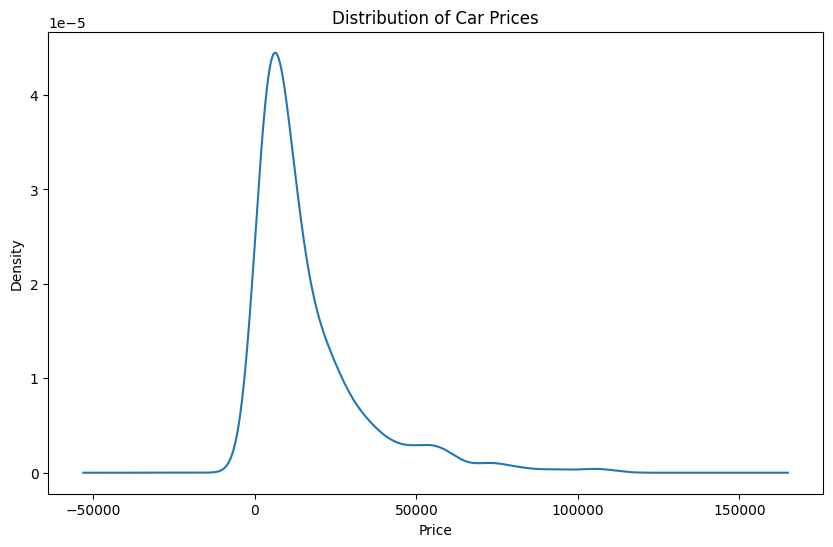

In [7]:
# kde plot of price
plt.figure(figsize=(10, 6))
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Density')
car['Price($)'].plot(kind='kde')
plt.show()

#### Price and Mileage
One of the most common factors both sellers and buyers factor into buying a used car is how much mileage is on the car. More mileage can increase risk of the car's performance as well as how much longer the car can be driven.

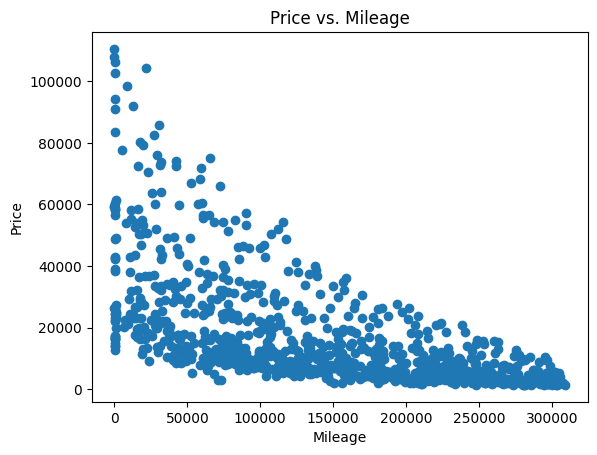

In [4]:
# Visualize mileage and price relationship
plt.figure()
plt.scatter(car['Mileage(km)'], car['Price($)'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Price vs. Mileage')
plt.show()

#### Price and Age
The next biggest factor that matters to both parties is the age of the car. We want to see this distribution in our dataset.

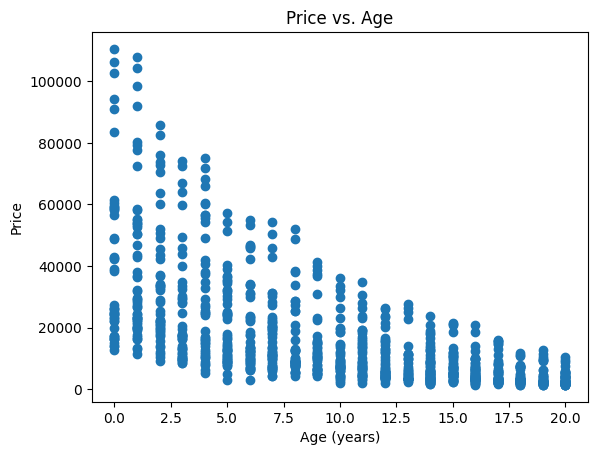

In [5]:
# Visualize price an age relationship
plt.figure()
plt.scatter(car['CarAge'], car['Price($)'])
plt.xlabel('Age (years)')
plt.ylabel('Price')
plt.title('Price vs. Age')
plt.show()

#### Price and Fuel Efficiency
One slightly less common factor is fuel efficiency. This factor, however, is just as important as it speaks to the performance on the car as well as the future investment into the car needed. Fuel efficiency essentially shows how well the car handles gas. With lower fuel efficiency, the car could still be a big financial investment as filling up the tank would add up if the fuel efficiency was low.

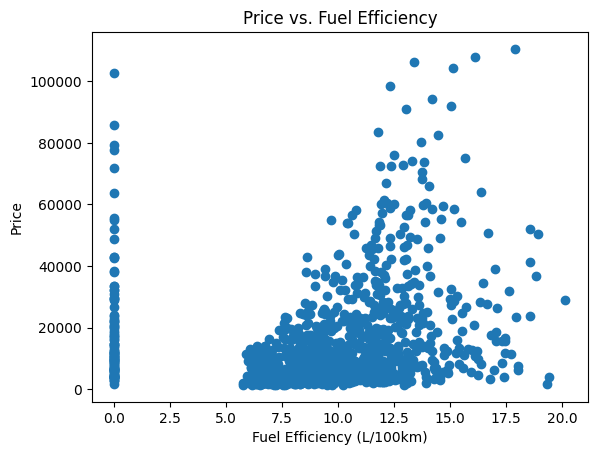

In [6]:
# View fuel efficiency and price relationship
plt.figure()
plt.scatter(car['FuelEfficiency(L/100km)'], car['Price($)'])
plt.xlabel('Fuel Efficiency (L/100km)')
plt.ylabel('Price')
plt.title('Price vs. Fuel Efficiency')
plt.show()

### Methods
We will be using kMeans clustering without any log transformations. 

First, we will clean our dataset and identify the variabe we want to investigate, which is price.

In [10]:
# Drop unnecessary columns and set target variable 
#keep Mileage(km), CarAge, Condition, AccidentHistory, FuelEfficiency(L/100km), Horsepower, BodyType, 

car_no_log = car.drop(columns=[
    'Brand', 'Model', 'Year', 'EngineSize(L)', 'Torque', 'Transmission',
    'DriveType', 'Doors', 'Seats', 'Color', 'Interior', 'Options', 'City',
    'Insurance', 'RegistrationStatus', 'FuelType', 'PricePerKm'
])

# Drop rows that are new cars (Condition = 'New')
car_no_log = car_no_log[car_no_log['Condition'] != 'New']
car_no_log = car_no_log[car_no_log['Mileage(km)'] != 0] # remove the outlier with 0 mileage but is still classified as used...

target = car_no_log['Price($)'] # set target variable after dropping rows

car_no_log = car_no_log.drop(columns=['Price($)']) # drop target variable from features
print(car_no_log.shape)
print(target.shape)

(954, 7)
(954,)


In [11]:
# One hot encode categorical variables
car_no_log = pd.get_dummies(car_no_log, columns=['Condition', 'BodyType', 'AccidentHistory'], drop_first=True, dtype=int)

In [12]:
#scale numeric data
scaler = StandardScaler()
scaled_no_log = scaler.fit_transform(car_no_log)

In [13]:
# kMeans with guess for k=3
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit model to training data
kmeans.fit(scaled_no_log)
# Predictions
clusters = kmeans.predict(scaled_no_log)
# Show clusters
car_no_log["Cluster"] = clusters
print(car_no_log["Cluster"])

33553    2
9427     1
199      0
12447    0
39489    0
        ..
33981    0
31260    0
12292    2
42286    1
13664    0
Name: Cluster, Length: 954, dtype: int32


In [14]:
# Group Clusters by mean
car_no_log.groupby("Cluster").mean()

,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes
Cluster,,,,,,,,,,,
0,10.207729,153272.666667,343.483092,9.463937,0.893720,0.000000,0.0,0.000000,0.000000,1.0,0.210145
1,10.485714,157473.180952,121.780952,6.799524,0.914286,0.000000,1.0,0.000000,0.000000,0.0,0.242857
2,10.633333,159348.090909,303.987879,11.185939,0.906061,0.239394,0.0,0.066667,0.621212,0.0,0.218182


In [15]:
#centers of clusters
print(kmeans.cluster_centers_)

[[-0.035908   -0.03473862  0.4160794  -0.00222784 -0.02965421 -0.30047581
  -0.53127965 -0.15363968 -0.5231618   1.14208048 -0.02408908]
 [ 0.01198668  0.01348024 -1.06069701 -0.65060241  0.03968089 -0.30047581
   1.8822479  -0.15363968 -0.5231618  -0.87559504  0.05486276]
 [ 0.03742032  0.03500284  0.15299849  0.41681465  0.01195108  0.56817245
  -0.53127965  0.29051866  0.9892514  -0.87559504 -0.00469182]]


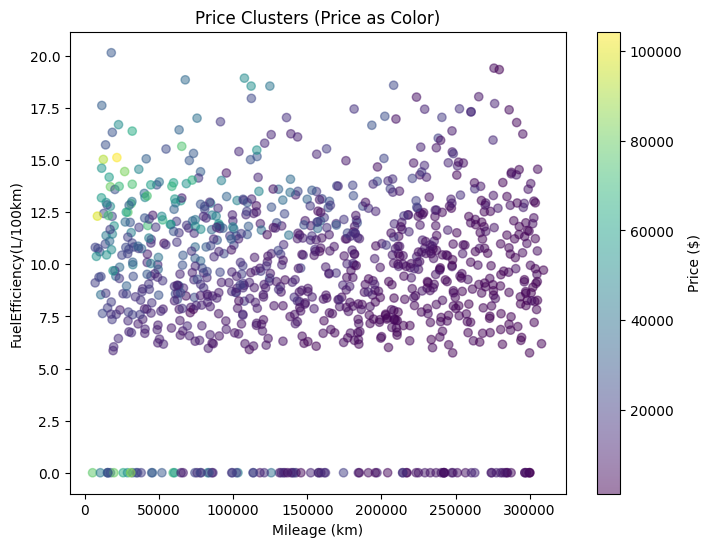

In [16]:
# Visualization of top variables
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    car_no_log["Mileage(km)"],
    car_no_log["FuelEfficiency(L/100km)"],
    c=target,
    alpha = 0.5
)
plt.colorbar(scatter, label="Price ($)")
plt.xlabel("Mileage (km)")
plt.ylabel("FuelEfficiency(L/100km)")
plt.title("Price Clusters (Price as Color)")
plt.show()


#### These clusters are not clear. We will repeat the process but take the log of the data before scaling it. This will help with dramatic skew in the data.

In [17]:
# Drop unnecessary columns and set target variable

#keep Mileage(km), CarAge, Condition, AccidentHistory, FuelEfficiency(L/100km), Horsepower, BodyType, 
car_df = car.drop(columns=[
    'Brand', 'Model', 'Year', 'EngineSize(L)', 'Torque', 'Transmission',
    'DriveType', 'Doors', 'Seats', 'Color', 'Interior', 'Options', 'City',
    'Insurance', 'RegistrationStatus', 'FuelType', 'PricePerKm'
])

# Drop rows that are new cars (Condition = New)
car_df = car_df[car_df['Condition'] != 'New']
car_df = car_df[car_df['Mileage(km)'] != 0] # remove the outlier with 0 mileage but is still classified as used...

target = car_df["Price($)"] #target variable

car_df = car_df.drop(columns=["Price($)"]) # Drop price column from features
car_df.shape

(954, 7)

In [18]:
# View the cleaned dataset
car_df.head()

,CarAge,Condition,Mileage(km),Horsepower,BodyType,AccidentHistory,FuelEfficiency(L/100km)
33553,18,Used,263330,206,SUV,No,12.15
9427,8,Used,115081,172,Hatchback,No,9.69
199,1,Used,15292,180,Sedan,No,7.91
12447,20,Used,287467,382,Sedan,No,0.00
39489,3,Damaged,44484,329,Sedan,No,11.02


We need to one-hot encode our categorical variables, so these can still be used in the clustering. We want to keep things like condition, accident history, and body type of the car as these factors would impact the price and quality of the car.

In [19]:
# One hot encode categorical variables
car_df = pd.get_dummies(car_df, columns=['Condition', 'BodyType', 'AccidentHistory'], drop_first=True, dtype=int)

We need to scale the numerical data to help the outliers from dominating the Euclidean distance calculation, and provde clearer clusters.

In [20]:
# scale numerical data with log to help with skew and make clearer clusters
car_df["Mileage(km)"] = np.log1p(car_df["Mileage(km)"])
car_df["FuelEfficiency(L/100km)"] = np.log1p(car_df["FuelEfficiency(L/100km)"])
car_df["Horsepower"] = np.log1p(car_df["Horsepower"])
car_df["CarAge"] = np.log1p(car_df["CarAge"])

In [21]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(car_df)


In [22]:
# kMeans with guess for k=3
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit model to training data
kmeans.fit(scaled_data)
# Predictions
clusters = kmeans.predict(scaled_data)
# Show clusters
car_df["Cluster"] = clusters
print(car_df["Cluster"])

33553    1
9427     1
199      0
12447    0
39489    0
        ..
33981    0
31260    0
12292    1
42286    1
13664    0
Name: Cluster, Length: 954, dtype: int32


In [23]:
# Group Clusters by mean
car_df.groupby("Cluster").mean()

,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes
Cluster,,,,,,,,,,,
0,2.216084,11.664531,5.782954,2.210597,0.906694,0.160243,0.00000,0.0,0.00000,0.839757,0.202840
1,2.298329,11.765291,5.154192,2.138090,0.899772,0.000000,0.47836,0.0,0.46697,0.000000,0.236902
2,2.296252,11.733180,5.950798,2.070746,0.863636,0.000000,0.00000,1.0,0.00000,0.000000,0.272727


In [24]:
#centers of clusters
print(kmeans.cluster_centers_)

[[-0.05990778 -0.05836466  0.51374669  0.04808758  0.01408551  0.28097231
  -0.53127965 -0.15363968 -0.5231618   0.81876128 -0.04172031]
 [ 0.06421585  0.06428124 -0.61782465 -0.04720188 -0.00924938 -0.30047581
   0.62325517 -0.15363968  0.61373195 -0.87559504  0.04048998]
 [ 0.06108084  0.0251961   0.81581394 -0.13570681 -0.13107638 -0.30047581
  -0.53127965  6.50873539 -0.5231618  -0.87559504  0.12695514]]


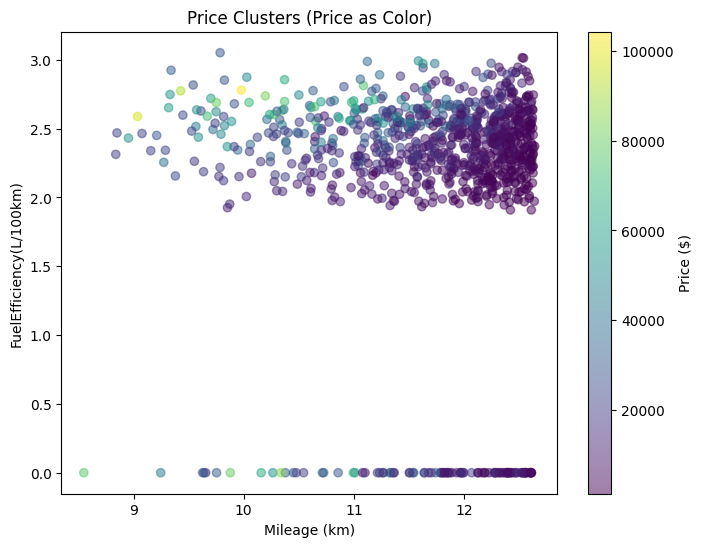

In [25]:
# Visualization of top variables
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    car_df["Mileage(km)"],
    car_df["FuelEfficiency(L/100km)"],
    c=target,
    alpha = 0.5
)
plt.colorbar(scatter, label="Price ($)")
plt.xlabel("Mileage (km)")
plt.ylabel("FuelEfficiency(L/100km)")
plt.title("Price Clusters (Price as Color)")
plt.show()


In [26]:
# Evaluate quality of clusters using silhouette score
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled_data)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_data, labels))

print("Total Variance for k=2-10:", inertias)
print("Silhouette Scores for k=2-10:", sil_scores)
print("Model Score for k=10:", km.score(scaled_data))
# %%

Total Variance for k=2-10: [8835.37576196463, 7828.859890098676, 6352.281003044234, 5895.2116754559465, 4797.429762823013, 4153.42631821107, 3652.775989840712, 3468.3279746716094, 3040.5191879955364]
Silhouette Scores for k=2-10: [0.2001202629922472, 0.22113776956247197, 0.29925414598814837, 0.2845553576810638, 0.33207636378656175, 0.3377599028469065, 0.35617069892245234, 0.36294562309135325, 0.3834489904821203]
Model Score for k=10: -3040.5191879955364


### Evaluation

We need to create an elbow plot to find the best k we should use.

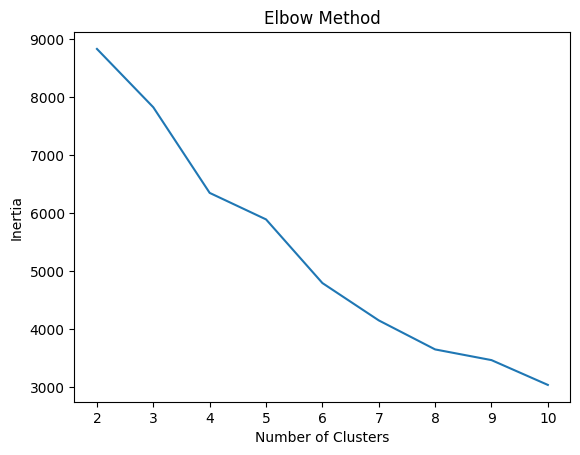

In [27]:
# Elbow plot to find ideal k (# of clusters)
plt.plot(k_range, inertias)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Silhouette scores can help us justify our chosen k.

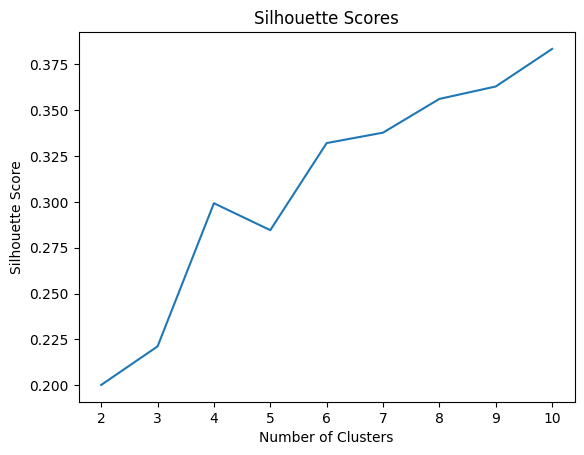

In [28]:
# Silhouette scores for k=2-10
plt.plot(k_range, sil_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

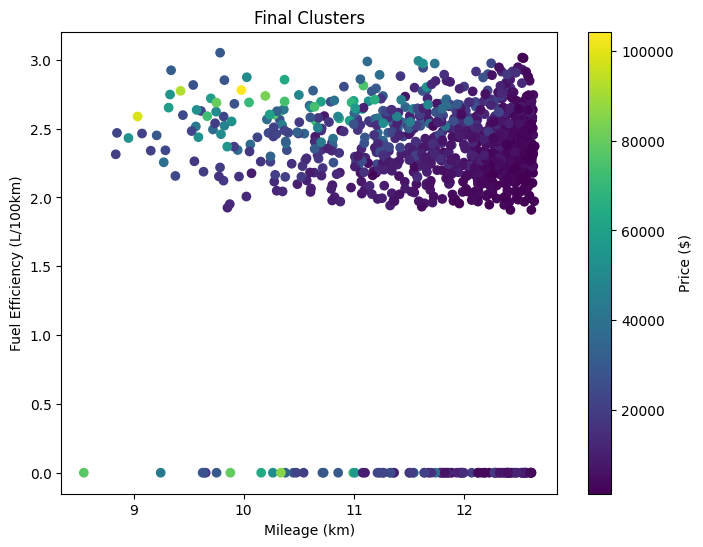

In [29]:
# Run final model with k=6
kmeans_final = KMeans(n_clusters=6, random_state=42)
car_df["Cluster_Final"] = kmeans_final.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
final = plt.scatter(
    car_df["Mileage(km)"],
    car_df["FuelEfficiency(L/100km)"],
    c=target
)

plt.colorbar(final, label="Price ($)")
plt.xlabel("Mileage (km)")
plt.ylabel("Fuel Efficiency (L/100km)")
plt.title("Final Clusters")
plt.show()

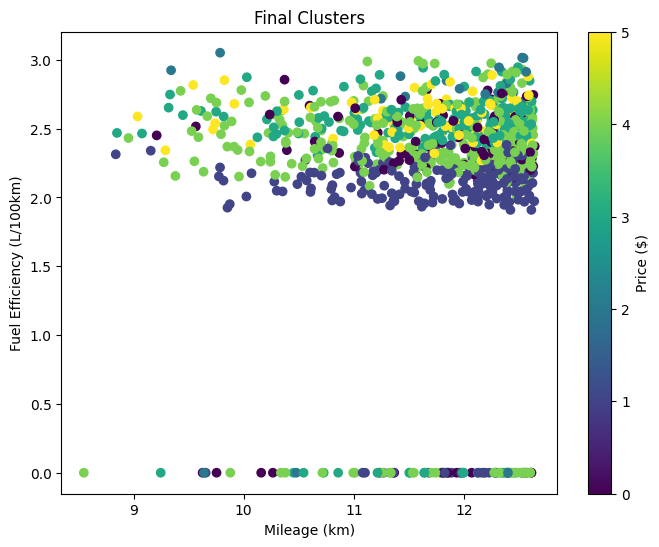

In [30]:
# labeling clusters

plt.figure(figsize=(8,6))
final = plt.scatter(
    car_df["Mileage(km)"],
    car_df["FuelEfficiency(L/100km)"],
    c=car_df["Cluster_Final"]
)

plt.colorbar(final, label="Price ($)")
plt.xlabel("Mileage (km)")
plt.ylabel("Fuel Efficiency (L/100km)")
plt.title("Final Clusters")
plt.show()

In [31]:
# Evaluate final clusters
print("Final Inertia:", kmeans_final.inertia_)
print("Final Silhouette:", silhouette_score(scaled_data, car_df["Cluster_Final"]))
# %%

Final Inertia: 4797.429762823013
Final Silhouette: 0.33207636378656175


In [32]:
# convert numerical data back to original for summary interpretation
car_df["Mileage(km)"] = np.expm1(car_df["Mileage(km)"])
car_df["FuelEfficiency(L/100km)"] = np.expm1(car_df["FuelEfficiency(L/100km)"])
car_df["Horsepower"] = np.expm1(car_df["Horsepower"])
car_df["CarAge"] = np.expm1(car_df["CarAge"])

In [33]:
# Bring back make and model
car_df["Brand"] = car["Brand"]
car_df["Model"] = car["Model"]

In [34]:
# Use the model to find underpriced and overpriced cars based on quality
car_df["Price($)"] = target
car_df["Cluster"] = car_df["Cluster_Final"]
car_df["Difference"] = car_df["Price($)"] - car_df.groupby("Cluster")["Price($)"].transform("median")


In [35]:
# Underpriced cars
car_df.sort_values("Difference").head(10)


,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes,Cluster,Cluster_Final,Brand,Model,Price($),Difference
18600,18.0,269559.0,388.0,10.77,1,1,0,0,0,0,1,5,5,Ford,Mustang,2634,-13283.0
46116,20.0,292890.0,372.0,14.54,1,1,0,0,0,0,0,5,5,Ford,Mustang,3028,-12889.0
35839,17.0,250833.0,420.0,14.28,1,1,0,0,0,0,1,5,5,Ford,Mustang,3235,-12682.0
20419,19.0,291221.0,410.0,16.80,1,1,0,0,0,0,0,5,5,Ford,Mustang,3236,-12681.0
35896,18.0,262746.0,391.0,13.91,1,1,0,0,0,0,0,5,5,Ford,Mustang,3859,-12058.0
44514,16.0,248023.0,210.0,10.22,0,0,0,0,0,1,0,4,4,Mazda,Mazda3,1425,-11963.0
44952,20.0,300517.0,332.0,9.95,1,1,0,0,0,0,0,5,5,Toyota,Supra,3966,-11951.0
6230,19.0,280572.0,192.0,9.50,0,0,0,0,0,1,0,4,4,Mazda,Mazda3,1495,-11893.0
10823,19.0,280449.0,236.0,6.87,0,0,0,0,0,1,0,4,4,Honda,Accord,1581,-11807.0
38340,20.0,301023.0,139.0,8.63,1,0,0,0,0,1,0,4,4,Toyota,Corolla,1725,-11663.0


In [36]:
# Overpriced cars
car_df.sort_values("Difference", ascending=False).head(10)


,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes,Cluster,Cluster_Final,Brand,Model,Price($),Difference
46976,1.0,21552.0,495.0,15.12,1,0,0,0,0,1,0,4,4,Mercedes-Benz,S-Class,104209,90821.0
8994,1.0,8400.0,506.0,12.31,1,1,0,0,0,0,0,5,5,Porsche,911 Carrera,98487,82570.0
23111,1.0,12416.0,472.0,15.03,1,0,0,0,0,1,0,4,4,BMW,7 Series,92058,78670.0
49029,2.0,30864.0,435.0,0.00,1,0,0,0,0,1,0,4,4,BMW,7 Series,85757,72369.0
40485,2.0,26799.0,429.0,14.45,1,0,0,0,0,1,0,4,4,BMW,7 Series,82634,69246.0
14492,1.0,17194.0,464.0,13.72,1,0,0,0,0,1,0,4,4,BMW,7 Series,80325,66937.0
3001,1.0,19501.0,853.0,0.00,1,0,0,0,0,1,0,4,4,Tesla,Model S,79321,65933.0
45637,1.0,5156.0,846.0,0.00,1,0,0,0,0,1,0,4,4,Tesla,Model S,77579,64191.0
7891,2.0,28972.0,505.0,12.50,1,0,0,0,0,1,0,4,4,Porsche,Panamera,76189,62801.0
42605,4.0,65318.0,523.0,15.66,1,0,0,0,0,1,0,4,4,Mercedes-Benz,S-Class,74992,61604.0


In [37]:
# Examine proportions of overpriced and underpriced cars by condition to see if used cars are more likely to be overpriced or underpriced
over = car_df[car_df["Difference"] > 0]
print('Overpriced Cars by Condition:')
print(over['Condition_Used'].value_counts())

under = car_df[car_df["Difference"] <= 0]
print('\nUnderpriced Cars by Condition:')
print(under['Condition_Used'].value_counts())

print("\nProportion of Used Cars Overpriced:", (over['Condition_Used'].sum() / car_df['Condition_Used'].sum()) * 100, "%")
print("Proportion of Used Cars Underpriced:", (under['Condition_Used'].sum() / car_df['Condition_Used'].sum()) * 100, "%")



Overpriced Cars by Condition:
Condition_Used
1    449
0     26
Name: count, dtype: int64

Underpriced Cars by Condition:
Condition_Used
1    412
0     67
Name: count, dtype: int64

Proportion of Used Cars Overpriced: 52.1486643437863 %
Proportion of Used Cars Underpriced: 47.851335656213706 %


In [38]:
# Analyze overpriced cars and underpriced cars by brand
print("Top 10 Overpriced Brands:")
print(over["Brand"].value_counts().head(10))

print("\nTop 10 Underpriced Brands:")
under["Brand"].value_counts().head(10)

Top 10 Overpriced Brands:
Brand
Audi             70
Mercedes-Benz    61
BMW              55
Porsche          47
Tesla            40
Toyota           38
Volkswagen       27
Ford             26
Hyundai          17
Kia              16
Name: count, dtype: int64

Top 10 Underpriced Brands:


Brand
Toyota           68
Mazda            58
Ford             45
Audi             36
Hyundai          35
Honda            34
Kia              33
Volkswagen       29
Tesla            28
Mercedes-Benz    26
Name: count, dtype: int64

### Conclusions

### Team Contribution